# 09_iris_classification.py — Iris osztályozás MLP-vel (PyTorch)

**Neurális hálók I. — Hajdu Csaba**

**Demonstrálja:**
- Többfokú osztályozás (softmax + CrossEntropyLoss)
- Tanítási ciklus PyTorch-ban
- Konfúziós mátrix és pontosság
- Batch Normalization hatása


In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

## Adat


In [7]:
iris = load_iris()
X, y = iris.data.astype(np.float32), iris.target.astype(np.int64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Xt = torch.tensor(X_train)
yt = torch.tensor(y_train)
Xv = torch.tensor(X_test)
yv = torch.tensor(y_test)

## Modellek


In [24]:
class IrisMLP(nn.Module):
    def __init__(self, use_batchnorm=False):
        super().__init__()
        layers = []
        layers.append(nn.Linear(4, 16))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(16))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(16, 8))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(8))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(8, 3))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_and_eval(model, name, epochs=300, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        out = model(Xt)
        loss = criterion(out, yt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            preds = model(Xv).argmax(dim=1)
            acc = (preds == yv).float().mean().item()
            if epoch % 20 == 0:
                print(f"{name}: epoch {epoch+1:3d} | train loss: {train_losses[-1]:.4f} | val acc: {acc*100:.1f}%")
        val_accs.append(acc)

    print(f"{name}: végső pontosság = {val_accs[-1]*100:.1f}%")
    return train_losses, val_accs, preds.numpy()

## Tanítás


In [25]:
torch.manual_seed(242)
model_plain = IrisMLP(use_batchnorm=False)
tl1, va1, preds1 = train_and_eval(model_plain, "MLP (BatchNorm nélkül)", epochs=300)

torch.manual_seed(242)
model_bn = IrisMLP(use_batchnorm=True)
tl2, va2, preds2 = train_and_eval(model_bn, "MLP + BatchNorm", epochs=300)

MLP (BatchNorm nélkül): epoch   1 | train loss: 1.1419 | val acc: 33.3%
MLP (BatchNorm nélkül): epoch  21 | train loss: 0.5115 | val acc: 73.3%
MLP (BatchNorm nélkül): epoch  41 | train loss: 0.1735 | val acc: 84.4%
MLP (BatchNorm nélkül): epoch  61 | train loss: 0.0697 | val acc: 95.6%
MLP (BatchNorm nélkül): epoch  81 | train loss: 0.0413 | val acc: 93.3%
MLP (BatchNorm nélkül): epoch 101 | train loss: 0.0305 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 121 | train loss: 0.0243 | val acc: 93.3%
MLP (BatchNorm nélkül): epoch 141 | train loss: 0.0201 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 161 | train loss: 0.0168 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 181 | train loss: 0.0142 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 201 | train loss: 0.0121 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 221 | train loss: 0.0103 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 241 | train loss: 0.0088 | val acc: 91.1%
MLP (BatchNorm nélkül): epoch 261 | train loss: 0.0075 | val acc

## Ábrák



Ábra mentve: 09_iris.png
Kész!


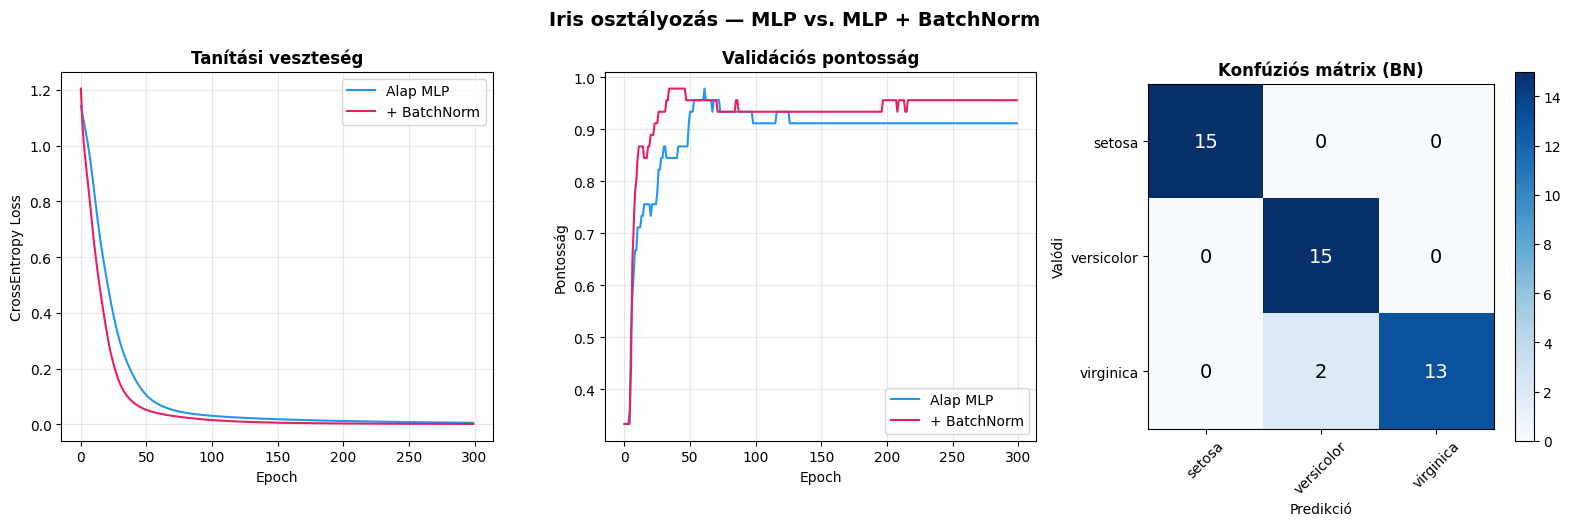

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss görbék
axes[0].plot(tl1, label="Alap MLP", color="#2196F3", linewidth=1.5)
axes[0].plot(tl2, label="+ BatchNorm", color="#E91E63", linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].set_title("Tanítási veszteség", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy
axes[1].plot(va1, label="Alap MLP", color="#2196F3", linewidth=1.5)
axes[1].plot(va2, label="+ BatchNorm", color="#E91E63", linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Pontosság")
axes[1].set_title("Validációs pontosság", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Konfúziós mátrix (BatchNorm modellre)
cm = confusion_matrix(y_test, preds2)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1, 2])
axes[2].set_yticks([0, 1, 2])
axes[2].set_xticklabels(iris.target_names, rotation=45)
axes[2].set_yticklabels(iris.target_names)
axes[2].set_xlabel("Predikció")
axes[2].set_ylabel("Valódi")
axes[2].set_title("Konfúziós mátrix (BN)", fontweight="bold")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im, ax=axes[2])

fig.suptitle("Iris osztályozás — MLP vs. MLP + BatchNorm", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("09_iris.png", dpi=150)
print("\nÁbra mentve: 09_iris.png")

print("Kész!")